## Домашнее задание 1 (10 баллов)

В рамках этой лабораторной работы вам предстоит освоить на практике этапы первичной обработки информации и ее последующего исследовательского анализа.Вы примените инструменты numpy, pandas, matplotlib и seaborn для решения проблемы, максимально приближенной к рабочим условиям.
Суть задачи — построение модели кредитного скоринга для определения надежности заявителя. Датасет содержит профили 1000 человек, описанных 20 параметрами, с итоговой маркировкой их кредитоспособности. Вам нужно будет привести данные в порядок, проанализировать их (включая создание графиков) и на основе выявленных закономерностей предложить простой метод расчета скорингового балла. Пояснения к полям данных доступны здесь:

https://www.rdocumentation.org/packages/evtree/versions/1.0-8/topics/GermanCredit

Любая созданная вами диаграмма должна быть аккуратно подписана (название, оси) и сопровождаться небольшим выводом, поясняющим, что на ней показано.

*Функции, которые могут пригодиться при оформлении графиков: `.show()`, `.title()`, `.xlabel()`, `.ylabel()`*

In [2]:
import pandas as pd
import numpy as np

### Задание 1 (0.0 балла)

Прочитайте средствами pandas файл с данными(файл 'german_credit.csv'). Выведите базовое представление таблицы (первые 5 и последние 5 строк, размер).

In [4]:
# your code here
data = pd.read_csv('german_credit.csv')

print("Первые 5:")
print(data.head())
#для красоты
print("\n" + "=========" + "\n")

print("Последние 5:")
print(data.tail())
#для красоты
print("\n" + "==========" + "\n")

print("Размер:")
print("Количество строк:")
print(data.shape[0])
print("Количество столбцов:")
print(data.shape[1])



Первые 5:
                status  duration                               credit_history  \
0  no checking account        18      all credits at this bank paid back duly   
1  no checking account         9      all credits at this bank paid back duly   
2           ... < 0 DM        12  no credits taken/all credits paid back duly   
3  no checking account        12      all credits at this bank paid back duly   
4  no checking account        12      all credits at this bank paid back duly   

      purpose  amount                     savings employment_duration  \
0  car (used)    1049  unknown/no savings account              < 1 yr   
1      others    2799  unknown/no savings account    1 <= ... < 4 yrs   
2  retraining     841               ... <  100 DM    4 <= ... < 7 yrs   
3      others    2122  unknown/no savings account    1 <= ... < 4 yrs   
4      others    2171  unknown/no savings account    1 <= ... < 4 yrs   

  installment_rate                   personal_status_sex other_d

### Задание 2 (0.5 балла)

Определите, есть ли пропуски в данных. Разделите признаки на количественные, бинарные, порядковые и категориальные.

In [87]:
# your code here
print("Количество пропусков по столбцам:")
print(data.isnull().sum())

# Теперь делим на типы
# Посмотрим, какие вообще есть
print(data.dtypes)

# Количественные - quantative/numerical
quan=[]
# Binary
bina=[]
# Categorical - категориальные
categ=[]
# Orderly :) - порядковые
ord=[]

# Как делать это автоматически не знала - пришлось подглядывать
# Пройдёмся по столбикам, собирая некоторую информацию и разделяя признаки
for c in data.columns:

  # Для определения типа нужно знать инф. о уникальных значениях
  uni=data[c].nunique()

  print(f"\n- {c} -")

  # Теперь уже к типу
  if data[c].dtype in ["int64","float64"]:
    if uni >10:
      quan.append(c)
      print("Количественный")
    else:
      ord.append(c)
      print("Порядковый")
  else:
    if uni==2:
      bina.append(c)
      print("Бинарный")
    elif uni<=10:
      if any(word in c for word in["duration","amount","age","rate","years"]):
        ord.append(c)
        print("Порядковый")
      else:
        categ.append(c)
        print("Категориальный ")


print(f"\nКоличественные признаки - {len(quan)}:")
print(quan)

print(f"\nБинарные признаки - {len(bina)}:")
print(bina)

print(f"\nПорядковые признаки - {len(ord)}:")
print(ord)

print(f"\nКатегориальные признаки - {len(categ)}:")
print(categ)



Количество пропусков по столбцам:
status                     0
duration                   0
credit_history             0
purpose                    0
amount                     0
savings                    0
employment_duration        0
installment_rate           0
personal_status_sex        0
other_debtors              0
present_residence          0
property                   0
age                        0
other_installment_plans    0
housing                    0
number_credits             0
job                        0
people_liable              0
telephone                  0
foreign_worker             0
credit_risk                0
dtype: int64
status                     object
duration                    int64
credit_history             object
purpose                    object
amount                      int64
savings                    object
employment_duration        object
installment_rate           object
personal_status_sex        object
other_debtors              object
pres

### Задание 3 (0.5 балла)

Выведите среднюю сумму кредита (колонка amount) в каждой категории (колонка purpose), воспользовавшись методом groupby.

In [25]:
# your code here
average_credit=data.groupby("purpose")["amount"].mean()

print(average_credit)

purpose
business               8209.333333
car (new)              5370.223301
car (used)             3066.983425
domestic appliances    2728.090909
furniture/equipment    2487.685714
others                 3062.948718
radio/television       1498.000000
repairs                3180.400000
retraining             4158.041237
vacation               1205.888889
Name: amount, dtype: float64


### Задание 4 (0.5 балла)


Какой процент клиентов моложе 30 лет (колонка age) снимает жилье (колонка housing)? А какой процент клиентов старше 40 лет снимает жилье?

In [47]:
# your code here
young = data[data["age"]<30]
old=data[data["age"]>40]

# Вывод, чтобы проверить, что всё ок
print(f"Клиенты, моложе 30: {len(young)}")
print(f"Клиенты, старше 40: {len(old)}")

young_housing=young[young["housing"]=="rent"]
young_percentage=(len(young_housing)/len(young))*100

print(f"\nПроцент клиентов моложе 30, снимающих жильё: {young_percentage}")

old_housing=old[old["housing"]=="rent"]
old_percentage=(len(old_housing)/len(old))*100

print(f"Процент клиентов за 40, снимающих жильё: {old_percentage}")

Клиенты, моложе 30: 369
Клиенты, старше 40: 272

Процент клиентов моложе 30, снимающих жильё: 66.66666666666666
Процент клиентов за 40, снимающих жильё: 68.01470588235294


### Задание 5 (0.5 балла)

 У скольких иностранцев (foreign_worker) число кредитов (number_credits) больше 3?

In [45]:
# your code here
foreign=data[data["foreign_worker"]=="yes"]

# Категориальный, поэтому такое не сработало :( - res=foreign[foreign["number_credits"]>3]

# Посмотрим, какими могут быть, и найдём категорию, означающую больше 3
print(f"Возможные значения: {foreign['number_credits'].unique()}")
res=foreign[foreign["number_credits"]=='4-5']

print(f"Колифество иностранцев, у которых больше 3 кредитов: {len(res)}")

Возможные значения: ['2-3' '1' '4-5']
Колифество иностранцев, у которых больше 3 кредитов: 1


### Задание 6 (1 балл)

In [38]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

Используя numpy и matplotlib, начнём с тренировки: постройте график функций $sin(x)$ и $cos(x)$ от $-\pi$ до $\pi$ из 100 точек c легендой и сеткой. Используйте для линий разные цвета, одна из них пусть будет пунктирной. Результат в этом и следующих заданиях на построение графиков должен получиться примерно как на картинке. Содержание подписей не должно обязательно совпадать, однако осмысленные подписи должны присутствовать на графиках.

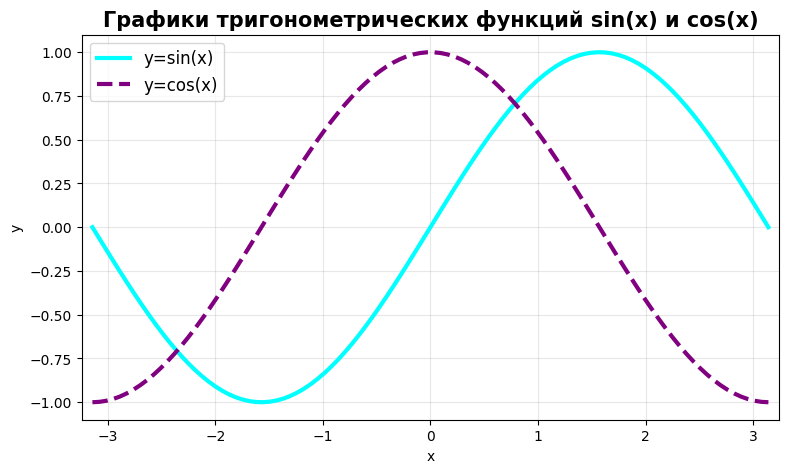

In [66]:
# your code here
# Значения иксов
x=np.linspace(-np.pi,np.pi,100)

y_sin=np.sin(x)
y_cos=np.cos(x)

plt.figure(figsize=(9,5))

plt.plot(x,y_sin,color="cyan",linestyle="-",linewidth=3,label="y=sin(x)")
plt.plot(x,y_cos,color="purple",linestyle="--",linewidth=3,label="y=cos(x)")

plt.title("Графики тригонометрических функций sin(x) и cos(x)",fontsize=15,fontweight="bold")

plt.xlabel("x",fontsize=10)
plt.ylabel("y",fontsize=10)

plt.legend(fontsize=12,loc="upper left")

plt.grid(True,alpha=0.3)

plt.xlim(-np.pi-0.1,np.pi+0.1)
plt.ylim(-1.1,1.1)

plt.show()




### Задание 7 (1 балл)

Рассмотрим сравнительное количество положительных и отрицательных кейсов в зависимости от размера текущего счёта. Постройте зеркальные горизонтальные гистограммы.

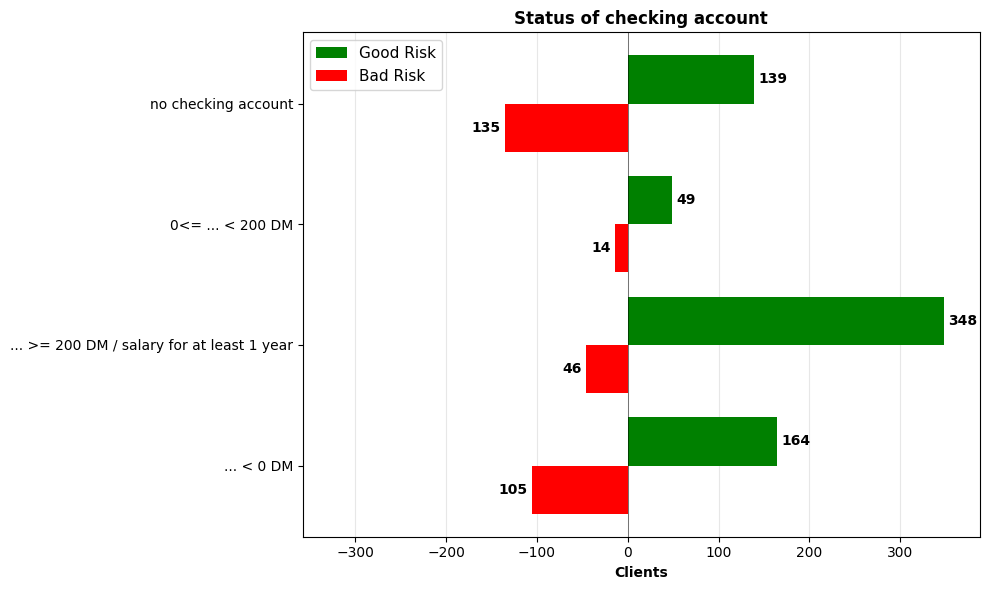

In [19]:
# your code here
# Табличка отдельная для удобства
status=pd.crosstab(data['status'], data['credit_risk'])

categ=status.index
positive=status['good']
negative=status['bad']

fig, ax = plt.subplots(figsize=(10, 6))

y_pos = np.arange(len(categ))

# Зелёный для хороших, красный для плохих
bars_pos = ax.barh(y_pos+0.2, positive, height=0.4, label='Good Risk',color='green', linewidth=1)
bars_neg = ax.barh(y_pos-0.2, -negative, height=0.4, label='Bad Risk', color='red', linewidth=1)

# Теперь значения добавляем
def add_value_labels(bars, is_neg=False):
    for bar in bars:
        width = bar.get_width()
        if is_neg:
            label_x = width - 5 if width < -10 else width - 8
            ax.text(label_x, bar.get_y() + bar.get_height()/2,f'{-int(width)}', ha='right', va='center', fontweight='bold')
        else:
            label_x = width + 5 if width > 10 else width + 8
            ax.text(label_x, bar.get_y() + bar.get_height()/2,f'{int(width)}', ha='left', va='center', fontweight='bold')

add_value_labels(bars_pos,is_neg=False)
add_value_labels(bars_neg,is_neg=True)

# Настраиваем график
ax.set_xlabel('Clients',fontsize=10,fontweight='bold')
ax.set_title('Status of checking account',fontsize=12,fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(categ, fontsize=10)

ax.axvline(x=0, color='black', linewidth=0.5, alpha=0.7)

ax.legend(loc='upper left', fontsize=11)

# Сеточка для лучшего понимания и просмотра
ax.grid(axis='x', alpha=0.3, linestyle='-')
ax.set_axisbelow(True)

max_val = max(max(positive), max(negative))
ax.set_xlim(-max_val-10, max_val+40)

plt.tight_layout()
plt.show()

# Гистограмма помогает посмотреть зависимость от разных характеристик статуса кредитного состояния
# А также понять, кому в большинстве случаев не надо доверять - принимаем решения по выдаче или невыдаче кредита


### Задание 8  (0.5 балла)

In [ ]:
import seaborn as sns

Теперь постройте гистограмму для сравнения количества положительных и отрицательных кейсов в зависимости от размера сберегательного счёта с помощью seaborn. Какой способ вам больше нравится с точки зрения трудоёмкости написания кода? А с точки зрения восприятия результата?

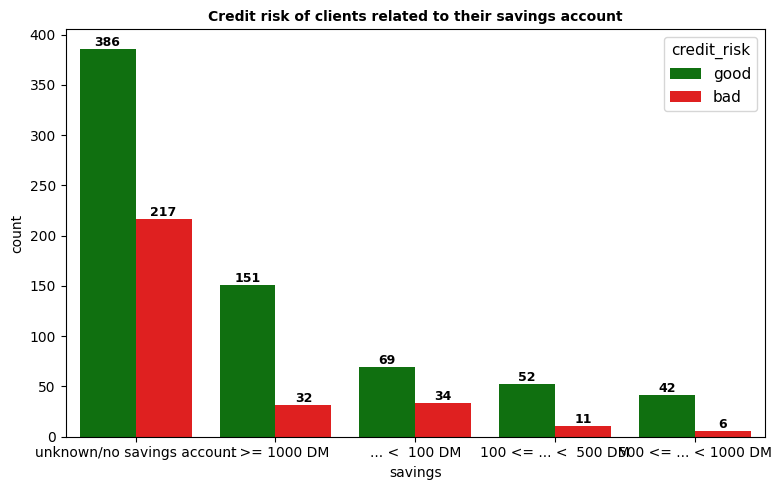

In [52]:
# your code here
plt.figure(figsize=(8, 5))

# Группируем столбцы
ax = sns.countplot(data=data, x='savings', hue='credit_risk',palette={'good': 'green', 'bad': 'red'},order=data['savings'].value_counts().index)

plt.title('Credit risk of clients related to their savings account',fontsize=10,fontweight='bold')
plt.xlabel('savings', fontsize=10)
plt.ylabel('count', fontsize=10)

# Добавляем значения на столбцы
for container in ax.containers:
    ax.bar_label(container, fontsize=9, fontweight='bold')

plt.legend(loc='upper right',title='credit_risk', title_fontsize=11, fontsize=11)
plt.tight_layout()
plt.show()

# Построили гистрограмму, показывающую зависимость кредитного статуса(риска) от разных видов сберегательного счёта

# В Seaborn значительно проще - гораздо меньше кода, да и методы проще - почти всё автоматически
# Но в Matplotlib можно самому всё настроить и сделать уникальный график какой-то, но искать это всё в интернете конечно сложновато

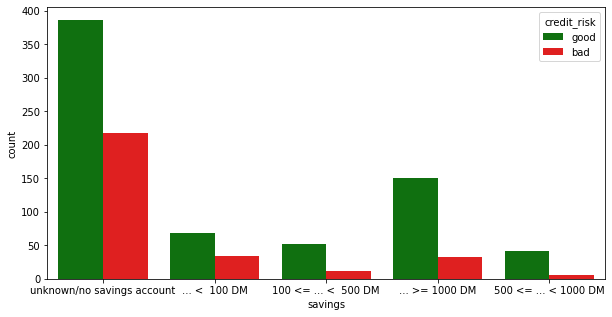

In [ ]:
# your code here

### Задание 9  (1 балл)

seaborn легко позволяет добавить ещё больше информации на один график. Для каждого размера сберегательного счёта мы можем оценить не только количество положительных и отрицательных кейсов, но и их распределение по возрасту, например. Постройте подходящую для этого визуализацию.

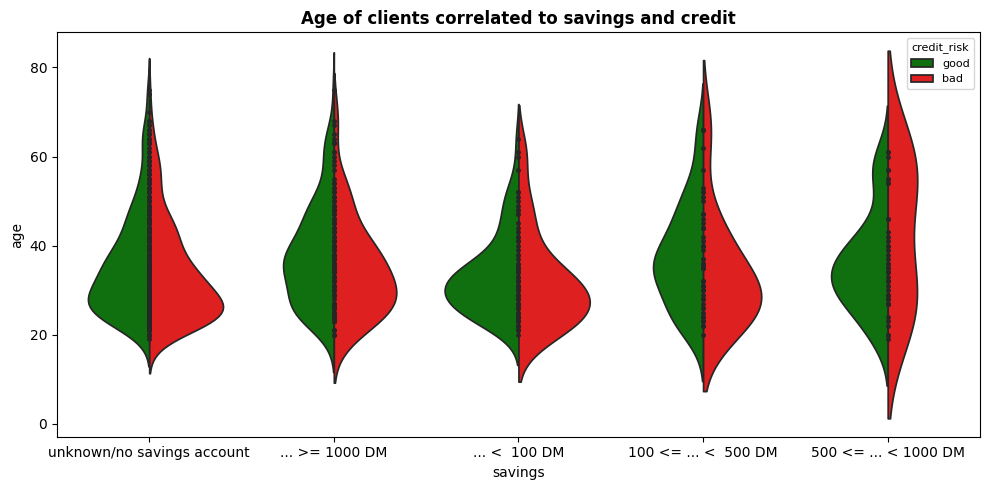

In [49]:
plt.figure(figsize=(10, 5))

violin_plot = sns.violinplot(data=data, x='savings', y='age', hue='credit_risk', palette={'good': 'green', 'bad': 'red'}, split=True, inner='point', order=data['savings'].value_counts().index)

plt.title('Age of clients correlated to savings and credit',fontsize=12,fontweight='bold')
plt.xlabel('savings account',fontsize=10)
plt.ylabel('age',fontsize=10)

plt.legend(loc='upper right',title='credit_risk', title_fontsize=8, fontsize=8)

plt.tight_layout()

plt.show()

# Можно посмотреть сравнительно распределение клиентов по возрасту, сберегательному счёту и кредитному риску
# Сразу три признака на одном графике! Да и красивый какой - сразу понятно некоторые характеристики, по которым можно обосновывать выдачу кредита


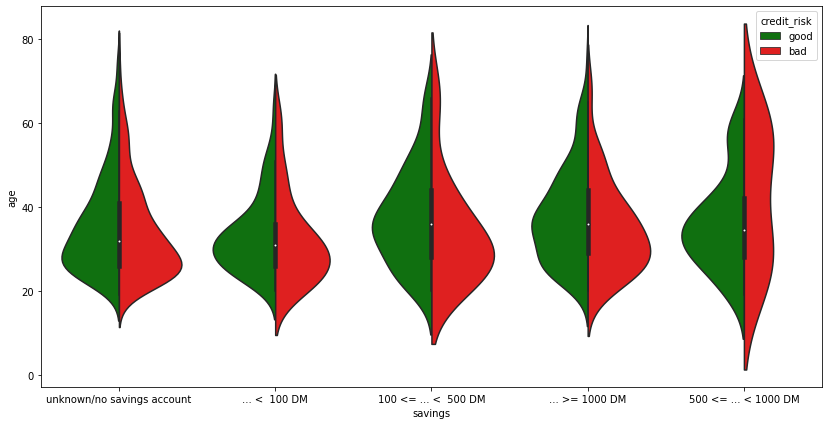

In [ ]:
# your code here

### Задание 10  (0.5 балла)

Заканчивая с гистограммами, посмотрим на распределение положительных и отрицательных кейсов по возрастам, разместив их друг над другом. Добавим распределение всех взятых кредитов.

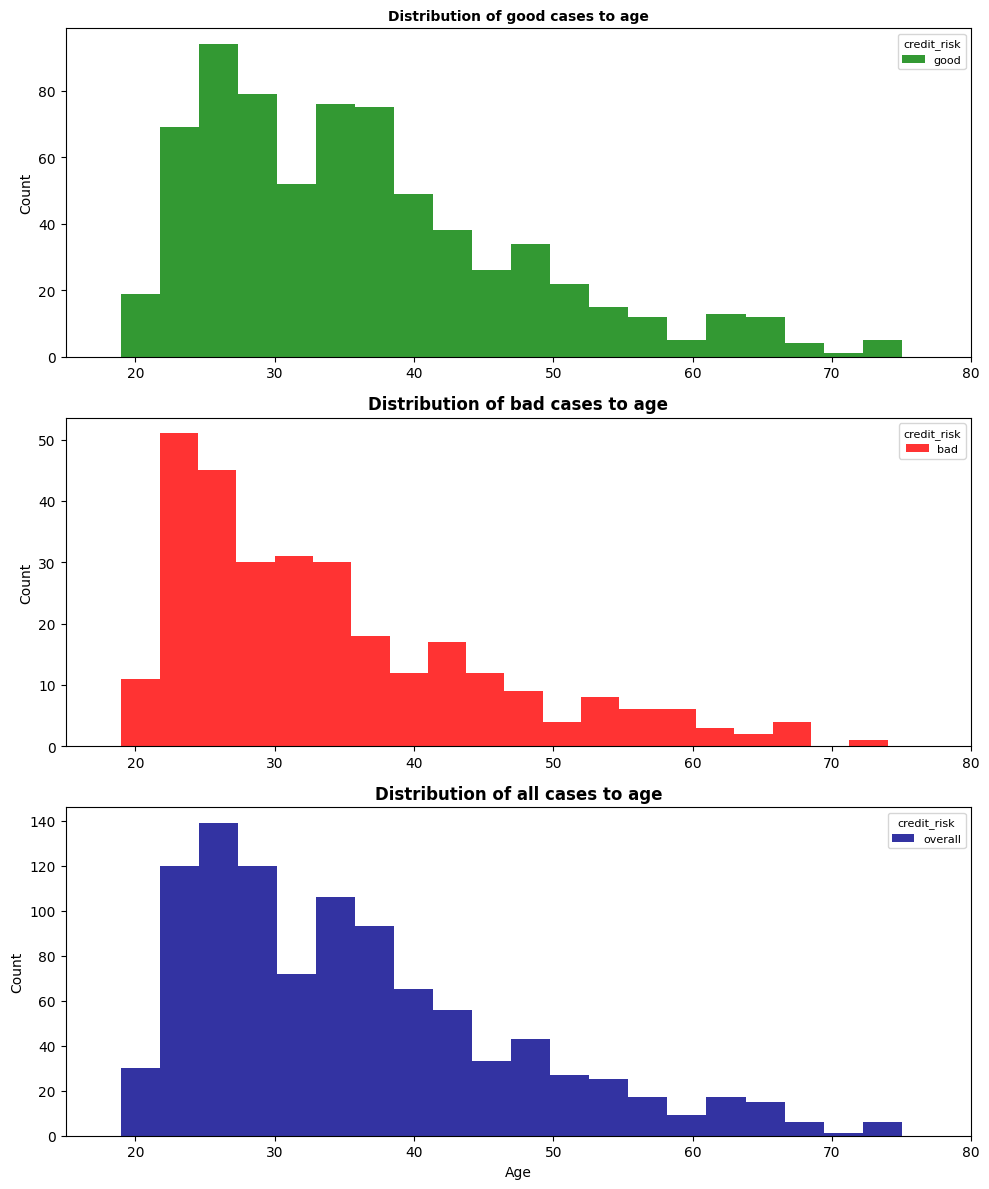

In [70]:
# Создаем фигуру с тремя подграфиками друг над другом
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12))

# 1: распределение good
good_cases = data[data['credit_risk'] == 'good']
ax1.hist(good_cases['age'], bins=20, color='green', alpha=0.8)
ax1.set_title('Distribution of good cases to age', fontsize=10, fontweight='bold')
ax1.set_ylabel('Count', fontsize=10)
ax1.set_xlim(15, 80)

ax1.legend(loc='upper right',title='credit_risk', title_fontsize=8, fontsize=8,labels=['good'])


# 2: распределение bad
bad_cases = data[data['credit_risk'] == 'bad']
ax2.hist(bad_cases['age'], bins=20, color='red', alpha=0.8)
ax2.set_title('Distribution of bad cases to age', fontsize=12, fontweight='bold')
ax2.set_ylabel('Count', fontsize=10)
ax2.set_xlim(15, 80)

ax2.legend(loc='upper right',title='credit_risk', title_fontsize=8, fontsize=8,labels=['bad'])


# 3: распределение всех
ax3.hist(data['age'], bins=20, color='darkblue', alpha=0.8, label='Все кредиты')
ax3.set_title('Distribution of all cases to age', fontsize=12, fontweight='bold')
ax3.set_ylabel('Count', fontsize=10)
ax3.set_xlabel('Age', fontsize=10)
ax3.set_xlim(15, 80)

ax3.legend(loc='upper right',title='credit_risk', title_fontsize=8, fontsize=8,labels=['overall'])


plt.tight_layout()
plt.show()

# С помощью такого графика так же можно выяснить самые рискованные группы возрастов
# Можем заметить, что good/bad очень похожи
# А так же как оба случая bad/good склыдываются в один overall

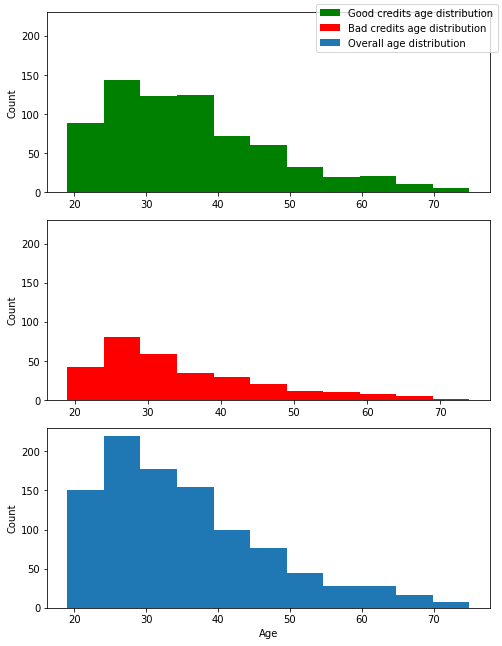

In [ ]:
# your code here

### Задание 11  (0.5 балла)

Не менее полезной иногда может быть диаграмма рассеяния. Постройте такую диаграмму с продолжительностью и размерами кредитов в качестве осей. Обозначьте положительные и отрицательные кейсы разными цветами.

/tmp/ipython-input-357132368.py:4: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = plt.scatter(data['duration'], data['amount'], c=data['credit_risk'].map({'good': 'green', 'bad': 'red'}), cmap='RdYlGn', alpha=0.7, s=60, edgecolors='white', linewidth=0.5)


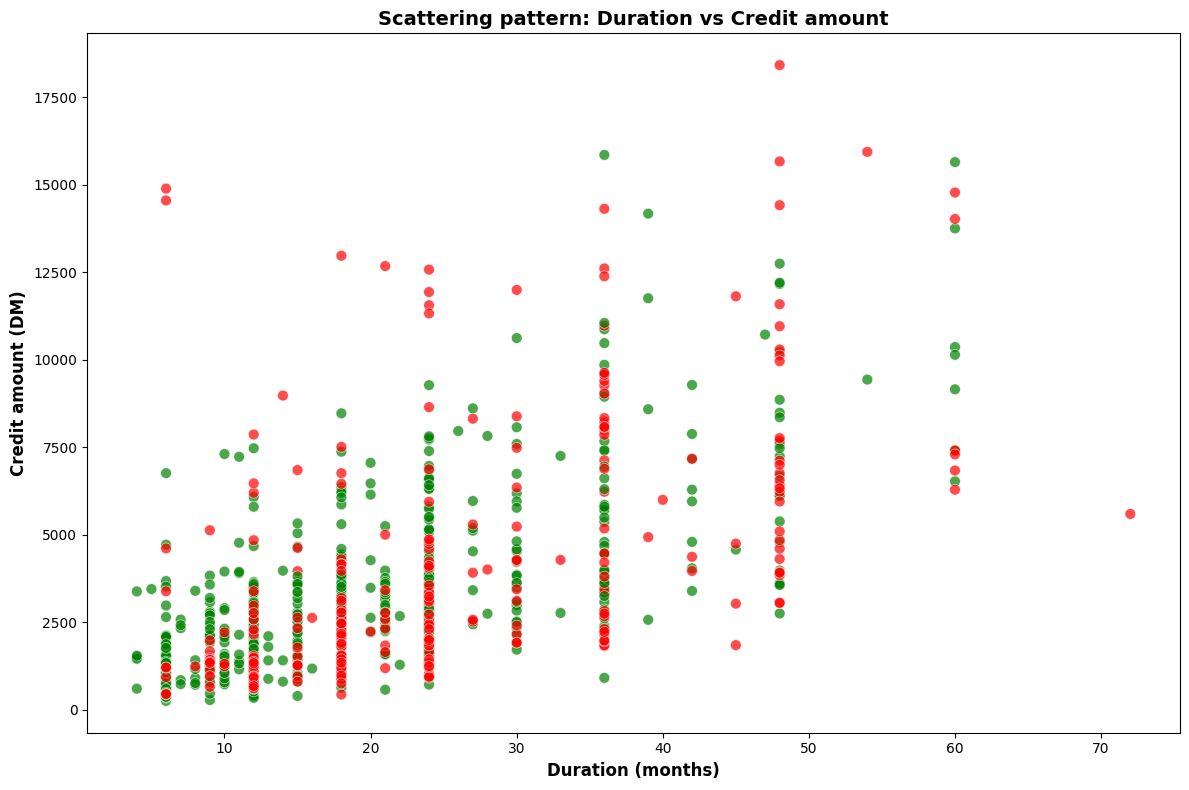

In [77]:
plt.figure(figsize=(12, 8))

# Создаем scatter plot с разными цветами для goodbad рисков
scatter = plt.scatter(data['duration'], data['amount'], c=data['credit_risk'].map({'good': 'green', 'bad': 'red'}), cmap='RdYlGn', alpha=0.7, s=60, edgecolors='white', linewidth=0.5)

plt.title('Scattering pattern: Duration vs Credit amount',fontsize=14, fontweight='bold')
plt.xlabel('Duration (months)', fontsize=12, fontweight='bold')
plt.ylabel('Credit amount (DM)', fontsize=12, fontweight='bold')


plt.tight_layout()
plt.show()

# С помощью такого графика можно посмотреть разброс клиентов по рассматриваемым признкам
# Можно заметить положительную корреляцию между продолжительностью и суммой - более долгие связаны с суммами побольше
# Чёткого раздения по риску нет - плохие и хорошие распределены везде

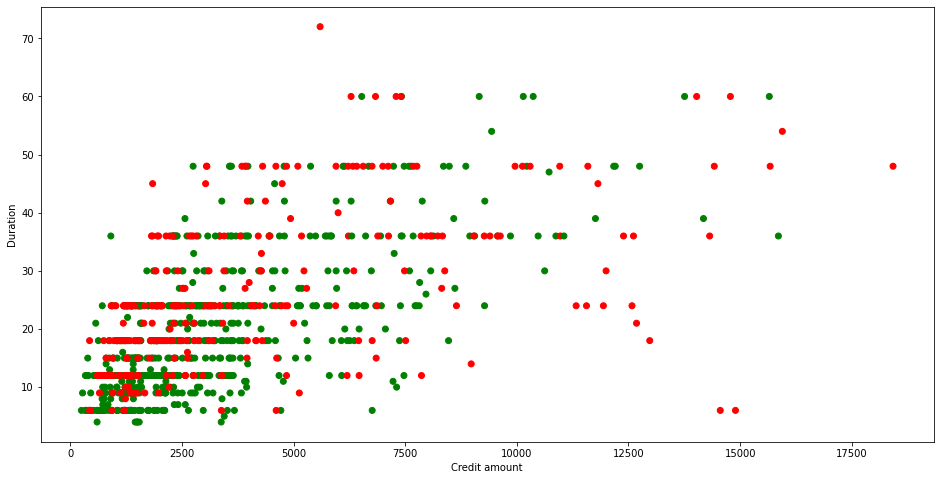

In [ ]:
# your code here

### Задание 12  (1 балл)

Продвинемся глубже. Постройте 3D версию диаграммы рассеяния, добавив ось с возрастом.

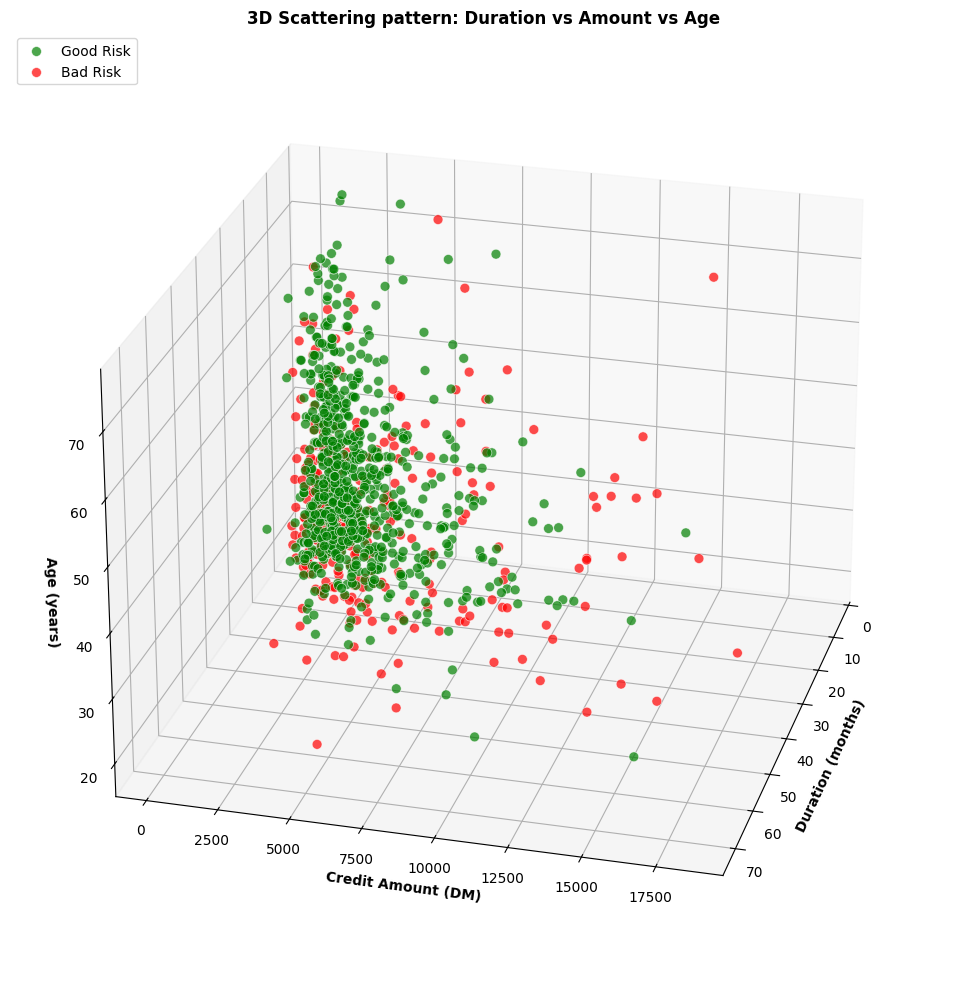

In [86]:
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

good_data = data[data['credit_risk'] == 'good']
bad_data = data[data['credit_risk'] == 'bad']

ax.scatter(good_data['duration'], good_data['amount'], good_data['age'], c='green', alpha=0.7, s=50, edgecolors='white', linewidth=0.5, label='Good Risk')

ax.scatter(bad_data['duration'], bad_data['amount'], bad_data['age'], c='red', alpha=0.7, s=50, edgecolors='white', linewidth=0.5, label='Bad Risk')

ax.set_title('3D Scattering pattern: Duration vs Amount vs Age', fontsize=12, fontweight='bold')
ax.set_xlabel('Duration (months)', fontsize=10, fontweight='bold')
ax.set_ylabel('Credit Amount (DM)', fontsize=10, fontweight='bold')
ax.set_zlabel('Age (years)', fontsize=10, fontweight='bold')

ax.legend(loc='upper left', bbox_to_anchor=(0, 1), fontsize=10)

# Настраиваю угол обзора - тут сложно поставить его для наибольшего понимания, как расположены разные точки
ax.view_init(elev=25, azim=15)
# И сеточку для удобства
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Опять сразу три признака на графике - можно найти, где есть скопления клиентов - зависимости!
# Также можно найти интересные взаимосвязи и выбросы для будущего анализа - есть ли большие группы плохих рисков где-то(чтобы их избегать), есть ли какие-то возраста для комбинаций длины и размера кредита

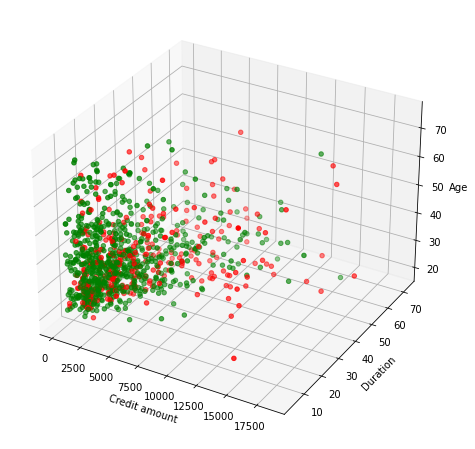

In [ ]:
# your code here

### Задание 13  (0.5 балла)

Представьте все порядковые и бинарные признаки в виде числовых значений {0, ..., n - 1}, где n это количество значений признака. Избавьтесь от категориальных признаков.

In [91]:
data_new = data.copy()

# Тут получилось очень много - постаралась прокомментировать по максимуму

# Количественные - quantative/numerical
quan=[]
# Binary
bina=[]
# Categorical - категориальные
categ=[]
# Orderly :) - порядковые
ord=[]

# РАЗДЕЛЯЕМ СНОВА ПРИЗНАКИ
# Скопировано из предыдущего задания
# Пройдёмся по столбикам, собирая некоторую информацию и разделяя признаки
for c in data_new.columns:

  # Для определения типа нужно знать инф. о уникальных значениях
  uni=data_new[c].nunique()

  print(f"\n- {c} -")

  # Теперь уже к типу
  if data_new[c].dtype in ["int64","float64"]:
    # Если уникальных много - количественный, иначе - порядковый
    if uni >10:
      quan.append(c)
    else:

      ord.append(c)
  else:
    # Разбираемся со строковыми значениями
    # 2 уникальных - бинарный
    if uni==2:
      bina.append(c)
    elif uni<=10:
      # Проверяем наличие "естественного" порядка по ключевым словам
      if any(word in c for word in["duration","amount","age","rate","years"]):
        ord.append(c)
      else:
        categ.append(c)

# Бинарный в 0 1
# Порядковые получается в 0...n-1
# Категориальные без порядка удаляем, а вот с порядком нужно преобразовать в 0...n-1


# БИНАРНЫЕ
# Сначала словарь, чтобы сохранить соответствия
binary_mappings = {}
for column in bina:
    # Берём столбец и смотрим, какие есть уникальные значения
    unique_vals = data_new[column].unique()

    # Теперь уже к преобразованию, с помощью enumerate в 0 первое и 1 второе
    mapping = {val: i for i, val in enumerate(unique_vals)}
    binary_mappings[column] = mapping

    # И применяем это преобразование
    data_new[column] = data_new[column].map(mapping)
    print(f"{column}: {mapping}")



# ПОРЯДКОВЫЕ
# Тут тоже пришлось подсмотреть, как это вообще делается
# Опять же словарь для хранения
ordinal_mappings = {}

def custom_sort_key(x):
    # С другими функциями были проблемы, поэтому пришлось вот так делать
    # Функция для сортировки порядковых признаков с интервалами
    try:
        # Обработка значений строкового типа '< 1 ', '>= 7 ' и т.д.
        if isinstance(x, str):
            # Убираем лишние пробелы и приводим к нижнему регистру
            x_clean = x.strip().lower()

            # Обработка числовых диапазонов в соответствии с таблицей
            if '...' in x_clean:
                # Для значений типа "1 <= ... < 4 yrs"
                # Разбиваем по точкам
                numbers = [float(num) for num in x_clean.split('...')[0].split() if num.replace('.', '').isdigit()]
                return numbers[0] if numbers else 0

            elif '<' in x_clean:
                # Для значений типа "< 1 yr"
                # Берём чуть меньше числа, чтобы этот диапазон шёл первее 1 <= 4
                numbers = [float(num) for num in x_clean.split('<')[1].split() if num.replace('.', '').isdigit()]
                return numbers[0] - 0.5 if numbers else 0  # Вычитаем 0.5 для правильного порядка

            elif '>=' in x_clean:
                # Для значений типа ">= 7 yrs"
                # Берём само число
                numbers = [float(num) for num in x_clean.split('>=')[1].split() if num.replace('.', '').isdigit()]
                return numbers[0] if numbers else 0

            else:
                # Для простых числовых значений
                numbers = [float(num) for num in x_clean.split() if num.replace('.', '').isdigit()]
                return numbers[0] if numbers else 0
        else:
            return float(x)

    except:
        # Ну и исключение для ошибок
        return 0

# Преобразуем данные порядковые признаки
for column in ord:
    # Проверка нужно ли преобразовывать вообще
    if data_new[column].dtype == 'object':
        # Нужно числовое кодирование - находим снова уникальные
        unique_vals = data_new[column].unique()

        # Пытаемся определить естественный порядок с помощью ключевых слов
        if any(word in column for word in ['duration', 'employment_duration', 'present_residence', 'installment_rate']):
            # Для временных интервалов создаем порядок от меньшего к большему

            try:
                # Сортируем с помощью созданной функцией
                sorted_vals = sorted(unique_vals, key=custom_sort_key)

                # И опять mapping для последовательного преобразования в номера
                mapping = {val: i for i, val in enumerate(sorted_vals)}
            except:
                # Если сортировка не удалась - какой-нибудь неприятный формат, используем простую нумерацию
                mapping = {val: i for i, val in enumerate(unique_vals)}
                print(f"Не удалось отсортировать {column}, используется простая нумерация :(")
        else:
            # Для остальных просто нумеруем по порядку
            mapping = {val: i for i, val in enumerate(unique_vals)}

        # Сохраняем и применяем
        ordinal_mappings[column] = mapping
        data_new[column] = data_new[column].map(mapping)
        print(f"{column}: {mapping}")
    else:
        # Числовые порядковые признаки уже в нужном формате - выводим
        print(f"{column}: уже числовой (0-{data_new[column].max()})")


# КАТЕГОРИАЛЬНЫЕ
# Удаляем категориальные признаки без того самого "естественного" порядка
columns_to_drop = categ
print(f"\nУдаляемые категориальные признаки: {columns_to_drop}")

data_new = data_new.drop(columns=columns_to_drop)


# РЕЗУЛЬТАТЫ
print(f"\nИтоговая форма данных: {data_new.shape}")
print(f"\nОставшиеся столбцы: {list(data_new.columns)}")

print("\nТипы данных после преобразования:")
print(data_new.dtypes)

print("\nПервые 5 строк преобразованных данных:")
print(data_new.head())


# Печатаем, что да как получилось
print(f"\nБинарные признаки ({len(bina)}):")
for col in bina:
    print(f"  {col}: {binary_mappings.get(col, 'уже числовой')}")

print(f"\nПорядковые признаки ({len(ord)}):")
for col in ord:
    if col in ordinal_mappings:
        print(f"  {col}: {ordinal_mappings[col]}")
    else:
        print(f"  {col}: уже числовой")

print(f"\nУдаленные категориальные признаки ({len(categ)}): {categ}")

print(f"\nКоличественные признаки ({len(quan)}): {quan}")

# Проверка!!
for column in data_new.columns:
    # Пропускаем изначально количественные признаки
    if column not in quan:
        # Смотрим, какие уникальные
        unique_vals = sorted(data_new[column].unique())
        n_unique = len(unique_vals)
        print(f"{column}: {unique_vals} (n={n_unique})")

        # Проверяем, что значения идут от 0 до n-1
        expected_range = list(range(n_unique))
        if unique_vals == expected_range:
            print(f"  Корректный диапазон: 0 - {n_unique-1}")
        else:
            print(f"  aaaa Неожиданный диапазон aaaa: {unique_vals}")


- status -

- duration -

- credit_history -

- purpose -

- amount -

- savings -

- employment_duration -

- installment_rate -

- personal_status_sex -

- other_debtors -

- present_residence -

- property -

- age -

- other_installment_plans -

- housing -

- number_credits -

- job -

- people_liable -

- telephone -

- foreign_worker -

- credit_risk -
people_liable: {'0 to 2': 0, '3 or more': 1}
telephone: {'no': 0, 'yes (under customer name)': 1}
foreign_worker: {'no': 0, 'yes': 1}
credit_risk: {'good': 0, 'bad': 1}
employment_duration: {'unemployed': 0, '< 1 yr': 1, '1 <= ... < 4 yrs': 2, '4 <= ... < 7 yrs': 3, '>= 7 yrs': 4}
installment_rate: {'< 20': 0, '20 <= ... < 25': 1, '25 <= ... < 35': 2, '>= 35': 3}

Удаляемые категориальные признаки: ['status', 'credit_history', 'purpose', 'savings', 'personal_status_sex', 'other_debtors', 'present_residence', 'property', 'other_installment_plans', 'housing', 'number_credits', 'job']

Итоговая форма данных: (1000, 9)

Оставшиеся ст

### Задание 14  (2 балла)

По результатам предыдущего задания у вас должна получиться таблица, в которой все признаки так или иначе представлены числовыми значениями. Попробуйте придумать на основе проведённых исследований данных какую-нибудь формулу, связывающую целевую переменную с признаками, не используя готовых инструментов машинного обучения. По желанию вы можете исключить ещё какие-то признаки, или, наоборот, сформировать новые на основе имеющихся. Возможно, вы захотите отмасштабировать большие наборы численных значений некоторых признаков с помощью интервалов. Цель: реализовать функцию, которая будет принимать на вход набор признаков для объекта выборки и возвращать прогноз целевой переменной (0 или 1). Например, вы можете просто сложить все признаки и возращать ноль, если сумма отрицательная, а в противном случае единицу. Но наверняка можно придумать лучше!
Данные уже разделены на набор для обучения, который вы можете использовать как угодно, и тестовый, на котором нужно будет проверить вашу точность. Постарайтесь достичь точности хотя бы 0.6.

In [103]:
# Я попыталась, но ничего не получилось :( где-то потеряла статус и не смогла найти

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

data_new2 = data.copy()
# Сделаем чудеса с целевой переменной
data_new2['credit_risk'] = data_new2['credit_risk'].map({'good': 1, 'bad': 0})


# Преобразуем признаки, смотря на графики/гистограммы из предыдущих заданий, ну и чутка своего
def func(df):
  df_new=df.copy()


  # Сначала разберёмся с бинарными
  df_new['foreign_worker'] = df_new['foreign_worker'].map({'yes': 1, 'no': 0})
  df_new['telephone'] = df_new['telephone'].map({'yes': 1, 'no': 0})


  # Теперь порядковые
  # Статус счёта - лучше - ниже риск
  stat_mapping = {'no checking account': 2, '... < 0 DM': 1, '0<= ... < 200 DM': 0, '... >= 200 DM / salary for at least 1 year': 0}
  df_new['status'] = df_new['status'].map(stat_mapping)


  # Сберегательный счёт - больше - ниже риск
  save_mapping = {'unknown/no savings account': 2, '... < 100 DM': 1, '100 <= ... < 500 DM': 0, '500 <= ... < 1000 DM': 0, '... >= 1000 DM': 0}
  df_new['savings'] = df_new['savings'].map(save_mapping)


  # История кредитная - лучше - ниже риск
  hist_mapping = {
        'delay in paying off in the past': 2,
        'critical account/other credits elsewhere': 2,
        'existing credits paid back duly till now': 1,
        'all credits at this bank paid back duly': 0,
        'no credits taken/all credits paid back duly': 0
    }
  df_new['credit_history'] = df_new['credit_history'].map(hist_mapping)


  # Наличие жилья в собственности - есть - ниже риск
  prop_mapping = {'rent': 1, 'own': 0, 'for free': 0}
  df_new['housing'] = df_new['housing'].map(prop_mapping)


  # Виды работы - лучше работа - ниже риск
  job_mapping = {
        'unemployed/unskilled - non-resident': 2,
        'unskilled - resident': 1,
        'skilled employee/official': 0,
        'manager/self-empl./highly qualif. employee': 0
    }
  df_new['job'] = df_new['job'].map(job_mapping)


  # Теперь с количественными признаками - по графикам
  # Длина кредита - больше - риск выше
  df_new['duration_scaled'] = np.where(df_new['duration'] > 24, 1, 0)
  # Сумма - больше - риск выше
  df_new['amount_scaled'] = np.where(df_new['amount'] > 5000, 1, 0)
  # Возраст - моложе - риск выше
  df_new['age_scaled'] = np.where(df_new['age'] < 30, 1, 0)

  return df_new


data_analyt=func(data_new)

main_columns = [
    'status', 'savings', 'credit_history', 'housing', 'job',
    'foreign_worker', 'telephone', 'duration_scaled', 'amount_scaled', 'age_scaled'
]
print("Используемые признаки:", main_columns)

# Теперь предсказание
def predict(Xtest: np.array) -> np.array:
    # your code here
    predicts = []

    for sample in Xtest:
        # Извлекаем признаки, их мы преобразовали в таком же порядке чуть пораньше
        status, savings, credit_history, housing, job, foreign_worker, telephone, duration_scaled, amount_scaled, age_scaled = sample

        # Сейчас начнём считать риск
        risk_score = 0

        # Веса признаков на основе нашего анализа данных, а также миллиона попыток
        risk_score += status * 2
        risk_score += savings * 1.5
        risk_score += credit_history * 3
        risk_score += housing * 1
        risk_score += job * 2
        risk_score += (1 - foreign_worker) * 1
        risk_score += (1 - telephone) * 0.5
        risk_score += duration_scaled * 1.5
        risk_score += amount_scaled * 1
        risk_score += age_scaled * 1

        # Пороговое значение для классификации - тут тоже потыкаться пришлось
        # Если риск-скор выше порога - предсказываем плохой кредит (0), иначе хороший (1)
        threshold = 4.5
        prediction = 0 if risk_score > threshold else 1

        predicts.append(prediction)

    return np.array(predicts)


# Вот тут начинается какая-то магия
# Данные для обучения
X = data_analyt[main_columns].values
y = data_analyt['credit_risk'].values


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=10)
# Используйте X_train и y_train на ваше усмотрение

print(f"\nРазмеры данных:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

# Анализ распределения целевой переменной
print(f"\nРаспределение целевой переменной в обучающей выборке:")
unique, counts = np.unique(y_train, return_counts=True)
for val, count in zip(unique, counts):
    print(f"  {['bad', 'good'][val]}: {count} ({count/len(y_train)*100:.1f}%)")

# Используем обучающую выборку для анализа (но не для обучения модели!!)
print("\nАнализ обучающей выборки для настройки порога:")
train_predictions = predict(X_train)
train_accuracy = accuracy_score(y_train, train_predictions)
print(f"Точность на обучающей выборке: {train_accuracy:.3f}")

# Тестируем на тестовой выборке
test_predictions = predict(X_test)
test_accuracy = accuracy_score(y_test, test_predictions)

print(f"\n" + "="*50)
print("=== РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ ===")
print(f"Точность на тестовой выборке: {test_accuracy:.3f}")

if test_accuracy >= 0.6:
    print("ЦЕЛЕВАЯ ТОЧНОСТЬ ДОСТИГНУТА!")
else:
    print("переделывай >:(")

# Примерчики
print(f"\nПримеры предсказаний:")
print("Формат: [статус, сбережения, история, жилье, работа, иностр., телефон, долгий_кредит, большая_сумма, молодой_возраст] → предсказание")
for i in range(min(5, len(X_test))):
    features = X_test[i]
    actual = y_test[i]
    predicted = test_predictions[i]
    print(f"Образец {i+1}: {features} → {['bad', 'good'][predicted]} (реальное: {['bad', 'good'][actual]})")


accuracy_score(y_test, predict(X_test))

KeyError: 'status'